# Generate Visualization - GFW & ASTD over time
This notebook generate and exports various visualization of ASTD fishing tracks aligned with GFW verification trajectories.

Formats :
- **Image** *(Paper Ready, overall or by month, and zoomed)*
    - Overall Tracks
    - Tracks segments
    - Image zoomed
- **Video** *(Fixed or Zoomed Video that follows the ship over time)*
    - Fast and minimal generation
    - Fast generation with "basic" map
    - Pretty generation (slower)

___
## 1. Loading data


In [1]:
import numpy as np

from backend import *
%load_ext autoreload
%autoreload 2

gfw_path = "D:/Stockage/GFW/"
astd_path = r"D:\Stockage\ASTD"
parquet_path = "../../examples/data/"

months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Periods for load_periods
periods = {
    2019: months,
    2020: months
    }

### Load ASTD and GFW

In [2]:
df_ASTD = load_periods('all_segments_periods2019_2020.parquet', source=astd_path, periods=periods, remove_nan_rows="default", usecols="default", progress=True)
df_ASTD = df_ASTD[df_ASTD['astd_cat'].str.contains('Fishing vessels')].copy()
df_ASTD["date_time_utc"] = pd.to_datetime(df_ASTD["date_time_utc"])
dt = df_ASTD['date_time_utc'].dt
df_ASTD['month'] = dt.to_period('M')
df_ASTD['date'] = dt.floor('D')
del dt
display(df_ASTD)

df_GFW = load_periods_gfw('gfw_2019_2020_bis.parquet', source=gfw_path, periods=periods)
df_GFW['date'] = pd.to_datetime(df_GFW['date'])
df_GFW['month'] = df_GFW['date'].dt.to_period('M')
display(df_GFW)

Loaded period ../../examples/data/all_segments_periods2019_2020.parquet, parameters ignored


C:\Users\virtu\AppData\Local\Temp\ipykernel_26004\2029649535.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ASTD['month'] = dt.to_period('M')


,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date
3,1892,2019-01-01 00:00:04+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.028629,540,29.700306,70.626442,2019-01,2019-01-01 00:00:00+00:00
4,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837,2019-01,2019-01-01 00:00:00+00:00
7,2946,2019-01-01 00:00:05+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.057516,119,-23.244274,66.155754,2019-01,2019-01-01 00:00:00+00:00
11,3034,2019-01-01 00:00:08+00:00,Iceland,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,3.720555,100,-13.740026,65.135429,2019-01,2019-01-01 00:00:00+00:00
17,3107,2019-01-01 00:00:14+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.718225,170,-23.810671,64.921066,2019-01,2019-01-01 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
85472769,1634,2020-12-31 23:59:51+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,1627.817993,364,10.828934,77.686615,2020-12,2020-12-31 00:00:00+00:00
85472770,2113,2020-12-31 23:59:51+00:00,Norway,FS Ice Class 1C,Fishing vessels,1000 - 4999 GT,993.163025,369,17.505766,74.173950,2020-12,2020-12-31 00:00:00+00:00
85472771,70,2020-12-31 23:59:51+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.551000,360,-22.718353,64.037857,2020-12,2020-12-31 00:00:00+00:00
85472774,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603,2020-12,2020-12-31 00:00:00+00:00


Loaded data ../../examples/data/gfw_2019_2020.parquet, parameters ignored


,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month
0,2019-01-01,-74.6,-106.5,440347000,0.8363,0.5983,2019-01
1,2019-01-01,-74.6,-106.3,440347000,0.2288,0.0000,2019-01
2,2019-01-01,-74.6,-105.7,440347000,0.2599,0.2599,2019-01
3,2019-01-01,-74.6,-106.4,440347000,0.3008,0.0000,2019-01
4,2019-01-01,-74.6,-106.6,440347000,1.8158,1.5694,2019-01
...,...,...,...,...,...,...,...
110192515,2020-12-31,79.2,8.8,273418680,0.8986,0.8986,2020-12
110192516,2020-12-31,79.3,8.6,273352280,0.1138,0.1138,2020-12
110192517,2020-12-31,79.3,8.4,273352280,0.8827,0.7363,2020-12
110192518,2020-12-31,79.3,8.5,273352280,1.1450,0.9033,2020-12


### Loading ASTD Tracks

In [3]:
tracks = load_tracks("20192020fishing.parquet", df_ASTD, return_logs=True)  #, w_speed=0.2, w_time=0.4, w_dist=0.4, max_time_gap_hours=250, max_distance_km=600, return_logs=True)
tracks_log = tracks[1]
tracks = tracks[0].rename(columns={'segment_id': 'shipid'})

tracks['month'] = pd.PeriodIndex(tracks['month'], freq='M')

Loaded tracks ../../examples/data/20192020fishing.parquet, parameters ignored
Loaded tracks logs


### Loading matched mmsi-shipid

In [4]:
# Match parameters
lat_threshold = 59

t_astd = 0.9
t_gfw_high = 0.6
t_gfw_low = 0.8
n_small = 20

match = pd.read_csv(parquet_path + f"gfw_threshmatch2019_2020.{lat_threshold}{[t_astd, t_gfw_low, t_gfw_high, n_small]}.csv")
# match = pd.read_csv(parquet_path + f"gfw_strictmatch2019_2020.{lat_threshold}.csv")

match['month'] = pd.PeriodIndex(match['month'], freq='M')
match

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
0,273217010,2020-04,1952,1426,1451,1678,0.849821,0.982771,1.832592,1.832592,1.832592
1,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,1.827668
2,258535000,2020-10,1219,1301,1370,1513,0.859881,0.949635,1.809516,1.809516,1.809516
3,273451570,2020-09,324,1274,1290,1556,0.818766,0.987597,1.806363,1.806363,1.806363
4,277558000,2020-11,2082,1181,1192,1349,0.875463,0.990772,1.866235,1.866235,1.866235
...,...,...,...,...,...,...,...,...,...,...,...
2425,251153000,2020-06,1557,3,3,3,1.000000,1.000000,2.000000,2.000000,2.000000
2426,257046460,2020-10,478,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
2427,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000
2428,259616000,2019-08,21852,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000


In [5]:
merged = match.merge(tracks, on=['month', 'shipid'], how='inner')
merged

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid,track_id
0,273217010,2020-04,1952,1426,1451,1678,0.849821,0.982771,1.832592,1.832592,1.832592,1943
1,276806000,2020-10,641,1332,1355,1577,0.844642,0.983026,1.827668,1.827668,1.827668,2470
2,258535000,2020-10,1219,1301,1370,1513,0.859881,0.949635,1.809516,1.809516,1.809516,2557
3,273451570,2020-09,324,1274,1290,1556,0.818766,0.987597,1.806363,1.806363,1.806363,2535
4,277558000,2020-11,2082,1181,1192,1349,0.875463,0.990772,1.866235,1.866235,1.866235,2035
...,...,...,...,...,...,...,...,...,...,...,...,...
2425,251153000,2020-06,1557,3,3,3,1.000000,1.000000,2.000000,2.000000,2.000000,664
2426,257046460,2020-10,478,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000,1888
2427,231189000,2020-05,22009,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000,2228
2428,259616000,2019-08,21852,2,2,2,1.000000,1.000000,2.000000,2.000000,2.000000,1250


___
## 2. Select MMSI data
`mmsi`: The MMSI identifier to process.

`full_track`: The `track_id` at which to stop processing. If the given `mmsi` contains multiple overlapping track IDs, only the track IDs up to and including `full_track` are kept, with `full_track` treated as the final valid track. This ensures that, in cases of overlap, only the desired track sequence is retained.

`target_score` : filter the matching dataset between GFW and ASTD to only keep match with a certain score

In [25]:
mmsi = 231090000
full_track = None #1734
# track_ids = [188, 201, 576, 876, 1305, 1320]
target_score = None #2 = strict matching

match_target = match
merged_mmsi = merged[merged['mmsi'] == mmsi]

if target_score is not None:
    match_target= match_target[match_target['score']==target_score]
    merged_mmsi = merged_mmsi[merged_mmsi['score']==target_score]

track_ids = merged_mmsi['track_id'].unique().tolist()
tracks_mmsi = tracks[tracks['track_id'].isin(track_ids)].rename(columns={'segment_id': 'shipid'}).copy()
tracks_mmsi_shipids = tracks_mmsi['shipid'].unique().tolist()

match_mmsi = match_target[match_target['mmsi']==mmsi]
shipids_mmsi = match_mmsi['shipid'].unique().tolist()

df_ASTD_light = df_ASTD[df_ASTD['shipid'].isin(tracks_mmsi_shipids)].copy()

df_GFW_mmsi = df_GFW[(df_GFW['mmsi'] == mmsi)].copy()


if full_track is not None:
    ### Stop the track at a specific track_id (used to generate track not following GFW) - e.g. Last track over multiple month to represent error in trackbuilder
    track_ids = merged_mmsi[['mmsi', 'month','track_id']].drop_duplicates().sort_values(by="month")['track_id'].tolist()
    track_ids = track_ids[:track_ids.index(full_track) + 1]

    tracks_mmsi = tracks[tracks['track_id'].isin(track_ids)].rename(columns={'segment_id': 'shipid'}).copy()

    shipids_mmsi = list(set(
        tracks_mmsi_shipids
        + tracks_mmsi.loc[tracks_mmsi['track_id'] == full_track, 'shipid'].tolist()
    ))


In [26]:
merged_mmsi[['mmsi', 'month','track_id', 'shipid']].drop_duplicates()

,mmsi,month,track_id,shipid
2312,231090000,2020-12,2369,2547
2372,231090000,2020-11,2369,20


In [27]:
match_mmsi

,mmsi,month,shipid,match_n_mmsi,astd_n_ship,gfw_n_mmsi,ratio_gfw,ratio_astd,score,max_score_mmsi,max_score_shipid
2312,231090000,2020-12,2547,34,34,34,1.0,1.0,2.0,2.0,2.0
2372,231090000,2020-11,20,30,30,30,1.0,1.0,2.0,2.0,2.0


In [28]:
tracks_mmsi

,month,shipid,track_id
6524,2020-07,1969,2369
6525,2020-08,1838,2369
6526,2020-09,1649,2369
6527,2020-10,2859,2369
6528,2020-11,20,2369
6529,2020-12,2547,2369


 ### Preprocess dataframes for visualization

In [29]:
col_lat_astd = 'latitude'
col_lon_astd = 'longitude'

col_lat_gfw = 'cell_ll_lat'
col_lon_gfw = 'cell_ll_lon'


df_ASTD_mmsi = df_ASTD_light.merge(
    tracks_mmsi,
    on=['shipid', 'month'],
    how='inner'
    )

df_ASTD_mmsi["grid_lon"] = np.floor(df_ASTD_mmsi["longitude"] * 10).astype('int16')
df_ASTD_mmsi["grid_lat"] = np.floor(df_ASTD_mmsi["latitude"] * 10).astype('int16')
df_ASTD_mmsi['month'] = df_ASTD_mmsi['month'].dt.strftime("%Y-%m")

## Select a few months
# df_ASTD_mmsi = df_ASTD_mmsi[df_ASTD_mmsi['month'].isin(["2019-12", "2020-01", "2020-02"])]
df_ASTD_mmsi = df_ASTD_mmsi.sort_values(by='date_time_utc')

df_GFW_mmsi["grid_lon"] = (df_GFW_mmsi["cell_ll_lon"] * 10).astype('int16')
df_GFW_mmsi["grid_lat"] = (df_GFW_mmsi["cell_ll_lat"] * 10).astype('int16')
df_GFW_mmsi['month'] = df_GFW_mmsi['month'].dt.strftime("%Y-%m")

# df_GFW_mmsi = df_GFW_mmsi.drop_duplicates(subset=[col_lon_gfw, col_lat_gfw, 'date'])
# df_GFW_mmsi_days = df_GFW_mmsi['date'].unique()

In [30]:
df_ASTD_mmsi

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude,month,date,track_id,grid_lon,grid_lat
0,1969,2020-07-01 00:05:49+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1704.593994,378,-7.479126,62.118450,2020-07,2020-07-01 00:00:00+00:00,2369,-75,621
1,1969,2020-07-01 00:11:59+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1607.656006,370,-7.486915,62.132408,2020-07,2020-07-01 00:00:00+00:00,2369,-75,621
2,1969,2020-07-01 00:23:51+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,2803.461914,712,-7.467842,62.155926,2020-07,2020-07-01 00:00:00+00:00,2369,-75,621
3,1969,2020-07-01 00:29:59+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1564.259033,368,-7.447672,62.166317,2020-07,2020-07-01 00:00:00+00:00,2369,-75,621
4,1969,2020-07-01 00:36:09+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1611.458984,370,-7.426348,62.176792,2020-07,2020-07-01 00:00:00+00:00,2369,-75,621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26979,2547,2020-12-31 23:24:16+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,0.657000,721,-7.326915,62.071373,2020-12,2020-12-31 00:00:00+00:00,2369,-74,620
26980,2547,2020-12-31 23:30:24+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1.335000,368,-7.326897,62.071381,2020-12,2020-12-31 00:00:00+00:00,2369,-74,620
26981,2547,2020-12-31 23:36:26+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,1.752000,362,-7.326887,62.071365,2020-12,2020-12-31 00:00:00+00:00,2369,-74,620
26982,2547,2020-12-31 23:42:36+00:00,Faeroe Islands,FS Ice Class 1B,Fishing vessels,< 1000 GT,2.244000,370,-7.326892,62.071388,2020-12,2020-12-31 00:00:00+00:00,2369,-74,620


In [31]:
df_GFW_mmsi

,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours,month,grid_lon,grid_lat
87026,2019-01-01,62.0,-6.8,231090000,23.8249,0.0,2019-01,-68,620
200177,2019-01-02,62.0,-6.8,231090000,24.1827,0.0,2019-01,-68,620
331517,2019-01-03,62.0,-6.8,231090000,23.9002,0.0,2019-01,-68,620
467928,2019-01-04,62.0,-6.8,231090000,24.1336,0.0,2019-01,-68,620
594312,2019-01-05,62.0,-6.8,231090000,23.9719,0.0,2019-01,-68,620
...,...,...,...,...,...,...,...,...,...
109731184,2020-12-27,62.0,-7.4,231090000,23.9363,0.0,2020-12,-74,620
109870116,2020-12-28,62.0,-7.4,231090000,24.0472,0.0,2020-12,-74,620
109990380,2020-12-29,62.0,-7.4,231090000,24.0000,0.0,2020-12,-74,620
110085377,2020-12-30,62.0,-7.4,231090000,23.9580,0.0,2020-12,-74,620


___
## 3. Images Exports
### Paper ready

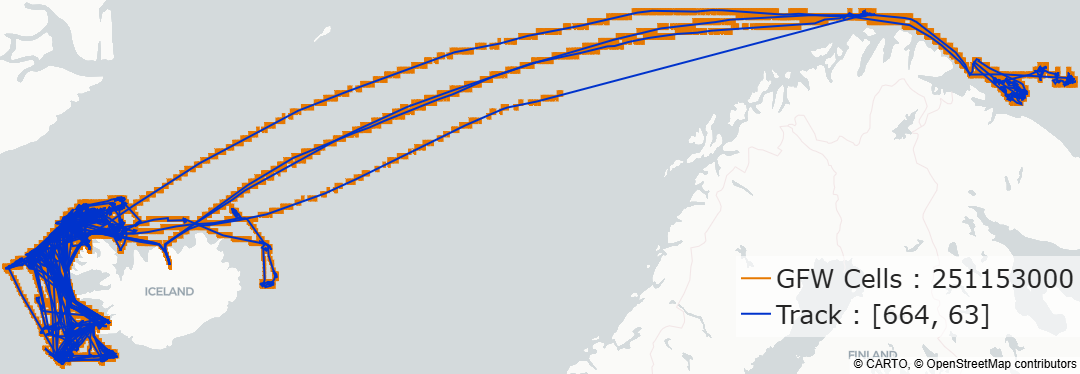

In [164]:
res = 0.1
pad = 0.2

anchor_legend = "right"
pos_legend = 1
font_legend = 25

# Remove unnecessary months
df1 = df_ASTD_mmsi[df_ASTD_mmsi['track_id'].isin(track_ids)]
df2 = df_GFW_mmsi[df_GFW_mmsi['month'].isin(df1['month'])]

lats = df1[col_lat_astd].values
lons = df1[col_lon_astd].values

fig = go.Figure()

#GFW plot grids
lons_all = []
lats_all = []

for _, row in df2.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, None]

fig.add_trace(go.Scattermap(
    lon=lons_all,
    lat=lats_all,
    mode="lines",
    line=dict(color="rgba(230, 120, 0, 1)", width=2),
    name=f"GFW Cells : {mmsi}"
    ))


fig.add_trace(go.Scattermap(
    lon=lons,
    lat=lats,
    mode="lines",
    line=dict(color="#0033cc", width=2),
    name=f"Track : {track_ids[0] if len(track_ids) == 1 else track_ids}"
    ))

lon_range = (df2[col_lon_gfw].max() + res) - df2[col_lon_gfw].min() + 2*pad

lat_range = (df2[col_lat_gfw].max() + res) - df2[col_lat_gfw].min() + 2*pad

mean_lat = (((df2[col_lat_gfw].max() + res) - df2[col_lat_gfw].min() + 2*pad) /2) + df2[col_lat_gfw].min()

aspect_ratio = (
    lon_range * np.cos(np.radians(mean_lat))
) / lat_range

width = 1080
height = width / aspect_ratio

fig.update_layout(
    autosize=False,
    width=width,
    height=height,
    map=dict(
        style="carto-positron",
        bounds=dict(
            west=df2[col_lon_gfw].min() - pad,
            east=df2[col_lon_gfw].max() + res + pad,
            south=df2[col_lat_gfw].min() - pad,
            north=df2[col_lat_gfw].max() + res + pad
            ),
        center=dict(
            lon=(df2[col_lon_gfw].min() + df2[col_lon_gfw].max() + res) / 2,
            lat=(df2[col_lat_gfw].min() + df2[col_lat_gfw].max() + res) / 2
            ),
        ),
    legend=dict(
        orientation="v",
        x=pos_legend,
        y=0.1,
        xanchor=anchor_legend,
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.6)"
        ),
    font=dict(size=font_legend),
    margin=dict(l=0, r=0, t=0, b=0),
    template="simple_white"
    )

img_bytes = pio.to_image(fig, format="png")
display(Image(img_bytes, retina=True))

## Output parameters
output_format = "pdf"

# tb.export_figure(fig, f"GFW2ASTD_{mmsi}.html")
pio.write_image(fig,
                f"outputs/{mmsi}_{track_ids}.{output_format}",
                format=output_format)


# pio.renderers.default = "browser"
# pio.renderers.default = "notebook"
# fig.show() #Show interactive map

### Paper ready per month

In [165]:
def set_layout(df = df2, zoom=1, center="all", x=0, xanchor="left", pad=pad, font_legend=25):
    res = 0.1
    if center != "all":
        center = [center] if type(center) != list else center
        mask = df['month'].isin(center)
        df = df.loc[mask, [col_lon_gfw, col_lat_gfw]].copy()


    # _center = dict(
    #     lon=(df[col_lon_gfw].min() + df[col_lon_gfw].max()) / 2,
    #     lat=(df[col_lat_gfw].min() + df[col_lat_gfw].max()) / 2
    #     )

    _bounds=dict(
        west=df[col_lon_gfw].min() - pad,
        east=df[col_lon_gfw].max() + res + pad,
        south=df[col_lat_gfw].min() - pad,
        north=df[col_lat_gfw].max() + res + pad
        )

    lon_range = (df[col_lon_gfw].max() + res) - df[col_lon_gfw].min() + 2*pad
    lon_len = lon_range / res

    lat_range = (df[col_lat_gfw].max() + res) - df[col_lat_gfw].min() + 2*pad
    lat_len = lat_range / res

    mean_lat = (((df2[col_lat_gfw].max() + res) - df2[col_lat_gfw].min() + 2*pad) /2) + df2[col_lat_gfw].min()

    aspect_ratio = (
        lon_len * np.cos(np.radians(mean_lat))
    ) / lat_len

    width = 1080
    height = width / aspect_ratio

    fig_zoom.update_layout(
        autosize=False,
        width=width,
        height=height,
        map=dict(
            style="carto-positron",
            # zoom=zoom,
            bounds=_bounds,
            # center=_center,
            ),
        legend=dict(
            orientation="v",
            x=x,
            y=0.1,
            xanchor=xanchor,
            yanchor="bottom",
            bgcolor="rgba(255,255,255,0.6)"
            ),
        font=dict(size=font_legend),
        margin=dict(l=0, r=0, t=0, b=0),
        )

#### Overview

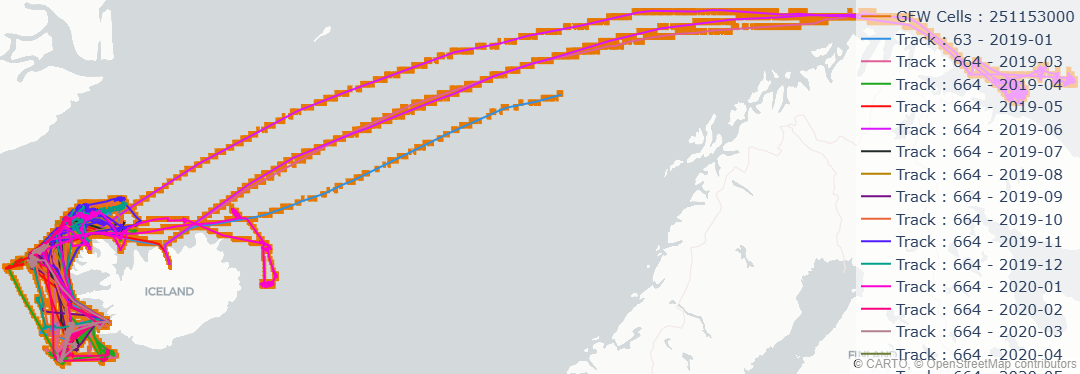

In [166]:
res = 0.1
pad = 0.2
font_legend = 15

# Remove unnecessary months
df1 = df_ASTD_mmsi[df_ASTD_mmsi['track_id'].isin(track_ids)]
df2 = df_GFW_mmsi[df_GFW_mmsi['month'].isin(df1['month'])]

months = pd.to_datetime(pd.concat([df1['month'], df2['month']])).dt.strftime("%Y-%m").unique()
month_colors = px.colors.qualitative.Dark24
color_map = {m: month_colors[i % len(month_colors)] for i, m in enumerate(sorted(months))}

fig_zoom = go.Figure()

lons_all = []
lats_all = []

for _, row in df2.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, None]

fig_zoom.add_trace(go.Scattermap(
    lon=lons_all,
    lat=lats_all,
    mode="lines",
    line=dict(color="rgba(230, 120, 0, 1)", width=2),
    name=f"GFW Cells : {mmsi}"
    ))


for (month, track_id), df_month in df1.groupby(['month', 'track_id']):
    df_month = df_month.sort_values('date_time_utc')

    fig_zoom.add_trace(go.Scattermap(
        lon=df_month[col_lon_astd],
        lat=df_month[col_lat_astd],
        mode="lines",
        name=f"Track : {track_id} - {month}",
        line=dict(color=color_map[month], width=2),
        # marker=dict(size=6),
        customdata=df_month['date_time_utc'],
        hovertemplate=(
            "Date: %{customdata}<br>"
            "Lat: %{lat}<br>"
            "Lon: %{lon}<extra></extra>"
        )
        ))

set_layout(df=df2, xanchor='right', x=1, font_legend=font_legend)

img_bytes = pio.to_image(fig_zoom, format="png")
display(Image(img_bytes, retina=True))

## Output parameters
output_format = "pdf"

# tb.export_figure(fig, f"GFW2ASTD_{mmsi}.html")
pio.write_image(fig_zoom,
                f"outputs/{mmsi}_{track_ids}_MONTH.{output_format}",
                format=output_format)

# pio.renderers.default = "browser"
# pio.renderers.default = "notebook"
# fig_zoom.show()  #Show interactive map

#### Zoomed In


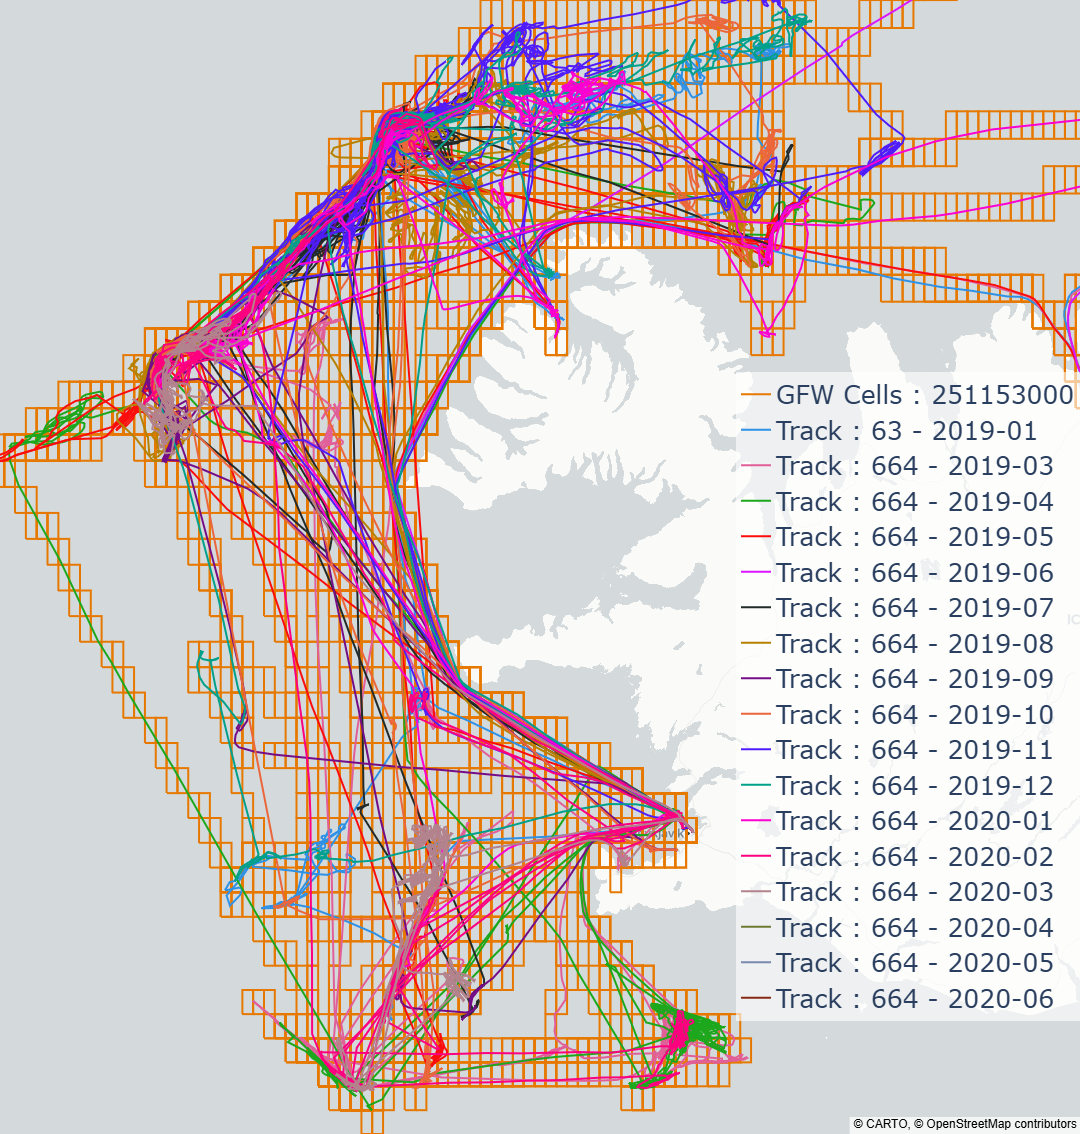

In [167]:
set_layout(df=df2, center="2019-05", x=1, xanchor="right")

img_bytes = pio.to_image(fig_zoom, format="png")
display(Image(img_bytes, retina=True))


pio.write_image(fig_zoom, f"outputs/{mmsi}_{track_ids}_MONTHZOOM.pdf", format="pdf")

___
## 4. Generate Video
### Preprocess data

In [33]:
df_ASTD_mmsi['date'] = pd.to_datetime(df_ASTD_mmsi['date'], utc=True)
df_GFW_mmsi['date'] = pd.to_datetime(df_GFW_mmsi['date'], utc=True)


# start = min(df_ASTD_mmsi["date_time_utc"].min(), df_GFW_mmsi["date_time_utc"].min())
# end = max(df_ASTD_mmsi["date_time_utc"].max(), df_GFW_mmsi["date_time_utc"].max())
#
# time_index = pd.date_range(start, end, freq="H")

# start_time = df_ASTD_mmsi["date_time_utc"].min().floor("D")
#
# GFW_work = df_GFW_mmsi[df_GFW_mmsi["date_time_utc"] >= start_time].sort_values(by='date_time_utc').copy()
#
# time_index = pd.to_datetime(
#     pd.concat([
#         df_ASTD_mmsi["date_time_utc"],
#         GFW_work["date_time_utc"]
#     ])
# ).sort_values()



## Old way that only return point with matching grid
remerged = df_GFW_mmsi.merge(df_ASTD_mmsi, on=["grid_lon", "grid_lat", "date", "month"], how="inner")

# work = select_subset(remerged, sample_per_day=50)
work = remerged.copy()

work.drop_duplicates(subset=['date', 'grid_lon', 'grid_lat'], inplace=True)
work.sort_values('date_time_utc', inplace=True)

work

### Matplotib video function

In [1]:
def matplot_generation(df, fps, dpi, bitrate, map=False, res = 0.1):
    df['datetime'] = df['datetime'].dt.strftime("%Y-%m-%d %H:%M:%S")

    # df = df[:100]

    if map:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        # tiler = cimgt.OSM(cache=True)
        # ax.add_image(tiler,8)
        # ax.coastlines()
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.set_global()
        ax.set_aspect('auto')
        ax.set_axis_off()

        fig.canvas.draw()
    else:
        fig, ax = plt.subplots()

    lats = df[col_lat_astd].values
    lons = df[col_lon_astd].values

    #GFW plot grids
    lons_all = []
    lats_all = []

    for _, row in df.iterrows():
        lon0 = row[col_lon_gfw]
        lat0 = row[col_lat_gfw]

        lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, np.nan]
        lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, np.nan]

    warnings.filterwarnings("ignore", message="invalid value encountered in linestrings")

    follow_ship = False
    zoom = 3

    if follow_ship and zoom != 0:
        pad_lon = (lons.max() - lons.min()) / zoom
        pad_lat = (lats.max() - lats.min()) / zoom
    else:
        ax.set_xlim(lons.min() - 0.3, lons.max() + 0.3)
        ax.set_ylim(lats.min() - 0.3, lats.max() + 0.3)
        # ax.set(xlim=[lons.min(), lons.max()], ylim=[lats.min(), lats.max()])


    if map:
        grid = ax.plot(lons_all[0], lats_all[0], "#e67800", label=f'GFW {mmsi}', transform=ccrs.PlateCarree())[0]
        line = ax.plot(lons[0], lats[0], "#0033cc", label=f'Track {track_ids[0] if len(track_ids) == 1 else track_ids}', transform=ccrs.PlateCarree())[0]
        point = ax.plot(lons[0], lats[0], 'ro', label='Time', transform=ccrs.PlateCarree())[0]
    else:
        grid = ax.plot(lons_all[0], lats_all[0], "#e67800", label=f'GFW {mmsi}')[0]
        line = ax.plot(lons[0], lats[0], "#0033cc", label=f'Track {track_ids[0] if len(track_ids) == 1 else track_ids}')[0]
        point = ax.plot(lons[0], lats[0], 'ro', label='Time')[0]
        # line = ax.plot(lons[0], lats[0], label=f'Track')[0]


    legend = ax.legend(loc='upper left')
    plt.tight_layout()


    def update_main(frame):
        point.set_label(f"{df['date_time_utc'].iloc[frame]}")

        # Position
        grid.set_data(lons_all[:(frame + 1) * 6], lats_all[:(frame + 1) * 6])
        line.set_data(lons[:frame + 1], lats[:frame + 1])
        point.set_data([lons[frame]], [lats[frame]])

        # Zoom and camera position
        if follow_ship:
            ax.set_xlim(lons[frame] - pad_lon, lons[frame] + pad_lon)
            ax.set_ylim(lats[frame] - pad_lat, lats[frame] + pad_lat)

        legend.get_texts()[2].set_text(point.get_label())

        pbar.update(1)
        return line, point


    pbar = tqdm(total=df.shape[0] + 1)  # set total to expected number of calls

    video = "VIDEO" if not map else "MAPVIDEO"

    ani = animation.FuncAnimation(fig=fig, func=update_main, frames=df.shape[0])
    ani.save(filename=f"videos/{mmsi}_{track_ids}_{video if follow_ship else video + "FIX"}.mp4", writer="ffmpeg", fps=fps, dpi=dpi, bitrate=bitrate)
    plt.close('all')
    pbar.close()

def imperfect_matplot_generation(df1, df2, fps, dpi, bitrate, map=False, res = 0.1):
    if map:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        # tiler = cimgt.OSM(cache=True)
        # ax.add_image(tiler,8)
        # ax.coastlines()
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.set_global()
        ax.set_aspect('auto')
        ax.set_axis_off()

        fig.canvas.draw()
    else:
        fig, ax = plt.subplots()

    lats = df1[col_lat_astd].values
    lons = df1[col_lon_astd].values


    def build_grid_lines(points, res):
        lons_all = []
        lats_all = []

        for lon0, lat0 in points:
            lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, np.nan]
            lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, np.nan]

        return np.array(lons_all), np.array(lats_all)

    grid_by_day_raw = {
        d: [(row[col_lon_gfw], row[col_lat_gfw]) for _, row in g.iterrows()]
        for d, g in df2.groupby('date')
    }
    grid_geom_by_day = {
        d: build_grid_lines(points, res)
        for d, points in grid_by_day_raw.items()
    }


    warnings.filterwarnings("ignore", message="invalid value encountered in linestrings")

    follow_ship = False
    zoom = 3

    if follow_ship and zoom != 0:
        pad_lon = (lons.max() - lons.min()) / zoom
        pad_lat = (lats.max() - lats.min()) / zoom
    else:
        ax.set_xlim(lons.min() - 0.3, lons.max() + 0.3)
        ax.set_ylim(lats.min() - 0.3, lats.max() + 0.3)
        # ax.set(xlim=[lons.min(), lons.max()], ylim=[lats.min(), lats.max()])

    if map:
        grid = ax.plot([], [], "#e67800", label=f'GFW {mmsi}', transform=ccrs.PlateCarree())[0]
        line = ax.plot([], [], "#0033cc", label=f'Track {track_ids[0] if len(track_ids) == 1 else track_ids}', transform=ccrs.PlateCarree())[0]
        point = ax.plot([], [], 'ro', label='Time', transform=ccrs.PlateCarree())[0]
    else:
        grid = ax.plot([], [], "#e67800", label=f'GFW {mmsi}')[0]
        line = ax.plot([], [], "#0033cc", label=f'Track {track_ids[0] if len(track_ids) == 1 else track_ids}')[0]
        point = ax.plot([], [], 'ro', label='Time')[0]
        # line = ax.plot(lons[0], lats[0], label=f'Track')[0]


    legend = ax.legend(loc='upper left')
    plt.tight_layout()


    def update_imperf(frame):
        current_day = df1.iloc[frame]['date']
        gx, gy = grid_geom_by_day.get(current_day, ([], []))

        # Position
        grid.set_data(gx, gy)
        # grid.set_data(lons_all[:(frame + 1) * 6], lats_all[:(frame + 1) * 6])
        line.set_data(lons[:frame + 1], lats[:frame + 1])
        point.set_data([lons[frame]], [lats[frame]])

        # Zoom and camera position
        if follow_ship:
            ax.set_xlim(lons[frame] - pad_lon, lons[frame] + pad_lon)
            ax.set_ylim(lats[frame] - pad_lat, lats[frame] + pad_lat)

        legend.get_texts()[2].set_text(f"{df1['date_time_utc'].iloc[frame]}")

        pbar.update(1)
        return line, grid, point


    pbar = tqdm(total=df1.shape[0] + 1)  # set total to expected number of calls

    video = "IMPERFECTVIDEO" if not map else "IMPERFECTMAPVIDEO"

    ani = animation.FuncAnimation(fig=fig, func=update_imperf, frames=df1.shape[0])
    ani.save(filename=f"videos/{mmsi}_{track_ids}_{video if follow_ship else video + "FIX"}.mp4", writer="ffmpeg", fps=fps, dpi=dpi, bitrate=bitrate)
    plt.close('all')
    pbar.close()

#### Non perfect follow-up

In [ ]:
# work = select_subset(remerged, sample_per_day=50)
work_gfw = df_GFW_mmsi.copy()

work_gfw.drop_duplicates(subset=['date', 'grid_lon', 'grid_lat'], inplace=True)
# work_gfw.sort_values('date_time_utc', inplace=True)
work_gfw

In [ ]:
imperfect_matplot_generation(df_ASTD_mmsi, work_gfw, map=False, fps=30, dpi=150, bitrate=1000)

### Fast generation without map (matplotlib)

In [ ]:
matplot_generation(work, map=False, fps=30, dpi=150, bitrate=2000)

### Fast generation with map (matplotlib + cartopy)

In [ ]:
matplot_generation(work, map=True, fps=60, dpi=150, bitrate=2000)

### Pretty but slow generation (plotly)

In [49]:
res = 0.1

df = work.copy()  #work[work['date_time_utc']>="2020-12-20"].copy()
df['date_time_utc'] = df['date_time_utc'].dt.strftime("%Y-%m-%d %H:%M:%S")

df = df[:100]

lats = df[col_lat_astd].values
lons = df[col_lon_astd].values

timestamps = df['date_time_utc'].values

fig = go.Figure()

follow_ship = False
fps = 20
writer = imageio.get_writer(
    f"videos/{mmsi}_{track_ids}_{"PRETTYVIDEO" if follow_ship else "PRETTYVIDEOFIX"}.mp4",
    fps=fps,
    codec="libx264",
    format="FFMPEG"
    )

#GFW plot grids
lons_all = []
lats_all = []

for _, row in df.iterrows():
    lon0 = row[col_lon_gfw]
    lat0 = row[col_lat_gfw]

    lons_all += [lon0, lon0 + res, lon0 + res, lon0, lon0, None]
    lats_all += [lat0, lat0, lat0 + res, lat0 + res, lat0, None]

fig.add_trace(go.Scattermap(
    lon=[],
    lat=[],
    mode="lines",
    line=dict(color="rgba(230, 120, 0, 1)", width=1),
    name=f"GFW Cells : {mmsi}"
    ))

fig.add_trace(go.Scattermap(
    lon=[],
    lat=[],
    mode="lines",
    line=dict(color="#0033cc", width=2),
    name=f"Track : {track_ids[0] if len(track_ids) == 1 else track_ids}"
    ))

fig.add_trace(go.Scattermap(
    lon=[],
    lat=[],
    mode="markers",
    line=dict(color="red", width=8),
    name=f"Time"
    ))

pad = 0.5

lat_mean = df[col_lat_gfw].mean()

lon_range = df[col_lon_gfw].max() - df[col_lon_gfw].min()
lat_range = df[col_lat_gfw].max() - df[col_lat_gfw].min()

lon_range_corr = lon_range * np.cos(np.radians(lat_mean))

aspect_ratio = lon_range_corr / lat_range

width = 1080
height = int(width / aspect_ratio)

bypad_height = height / lat_range

height += (bypad_height * pad)

fig.update_layout(
    autosize=False,
    width=width,
    height=height,
    map=dict(
        style="carto-positron",
        bounds=dict(
            west=df[col_lon_gfw].min() - pad,
            east=df[col_lon_gfw].max() + pad,
            south=df[col_lat_gfw].min() - pad,
            north=df[col_lat_gfw].max() + pad
            ),
        center=dict(
            lon=(df[col_lon_gfw].min() + df[col_lon_gfw].max()) / 2,
            lat=(df[col_lat_gfw].min() + df[col_lat_gfw].max()) / 2
            ),
        ),
    legend=dict(
        orientation="v",
        x=1,
        y=0.1,
        xanchor="right",
        yanchor="bottom",
        bgcolor="rgba(255,255,255,0.6)"
        ),
    font=dict(size=14),
    margin=dict(l=0, r=0, t=0, b=0),
    )

for i in trange(0, len(df)):
    fig.data[0].lon = lons_all[:(i + 1) * 6]
    fig.data[0].lat = lats_all[:(i + 1) * 6]

    fig.data[1].lon = lons[:i + 1]
    fig.data[1].lat = lats[:i + 1]


    fig.data[2].lon = [lons[i]]
    fig.data[2].lat = [lats[i]]
    fig.data[2].name = str(timestamps[i])


    img_bytes = pio.to_image(fig, format="png")
    writer.append_data(imageio.imread(img_bytes))

writer.close()
plt.close('all')
# pio.renderers.default = "browser"
# pio.renderers.default = "notebook"
# fig.show() #Show interactive map

  0%|          | 0/100 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1080, 946) to (1088, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
